# Basic Convolutional neural networks for denoising

In this notebook you will familiarize with the basic structure in keras of a denoising neural network.

I have provided you vectors of data, one noiseless, multiple with different levels of white, gaussian, noise, for supervised training

The data are are a numpy array arranged this way: NPix,NPix,Ndata
The data are 2D slices from multi-modality brain MR images

Image data have already been scaled to be in a similar intensity range

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.ndimage as ndi
from skimage.metrics import structural_similarity as ssim

import keras
from keras.models import Model

In the initial version, read the data with "low" noise

In [2]:
dataV = np.load('dataTrue.npy')
dataNoisy = np.load('dataNoise_small.npy')

### Take a look at some data

### Reshape the data

Keras wants the data index in the first dimension and a fourth dimension for the channel. Reshape them here

Also, split the data in training and validation (you can split at subject 1600, so it's replicable and the same for everyone.)

In [3]:
dataV = np.expand_dims(dataV,axis=-1)
dataV = np.transpose(dataV,(2,0,1,3))
dataNoisy = np.expand_dims(dataNoisy,axis=-1)
dataNoisy = np.transpose(dataNoisy,(2,0,1,3))

### Split train-val

In [28]:
outTest = dataV[1600:,:,:,:]
outTrain = dataV[:1600,:,:,:]
dataV = []
inpTest = dataNoisy[1600:,:,:,:].astype(np.float32)
inpTrain = dataNoisy[:1600,:,:,:].astype(np.float32)
dataNoisy=[]


# Define the neural network

Here, build a very basic neural network that downsamples only once and uses 16 filters in the first layer, 32 in the second and goes straight to the output

This way you can run a successfull training just on the CPU

In [4]:
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
from keras.optimizers import Adam

### Model Compilation and fit

set up the optimizer, learning rate, loss (MSE?) metrics (MAE?) and run .fit()

Visualize the fitting history

## Show one image of the denoising provided by the toy model

# U-NET
Build a complete U-NET now (even if "small" by U-net standards)

If you start with 16 filters and downsample 2 times it works well enough (and still trains on CPU)

## Evaluate the results

The neural network optimized the MSE between the input and the output. However, it's a good idea to also check the visual quality of the output.
1) plot some randomly chosen images from the validation dataset, compated to the ground truth
2) Compute the SSIM on the denoised images, using also gaussian smoothing as a comparison algorithm


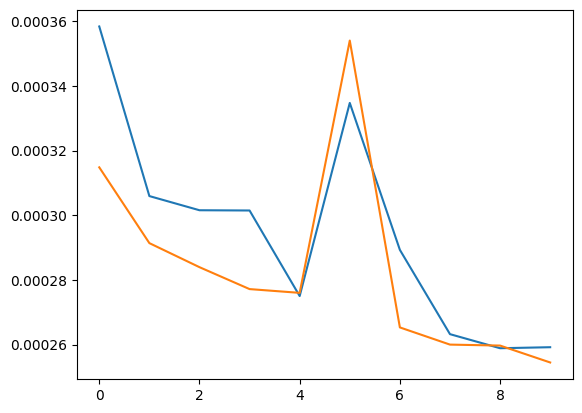

In [40]:
plt.plot(fitHistory.history['loss'][:])
plt.plot(fitHistory.history['val_loss'][:])

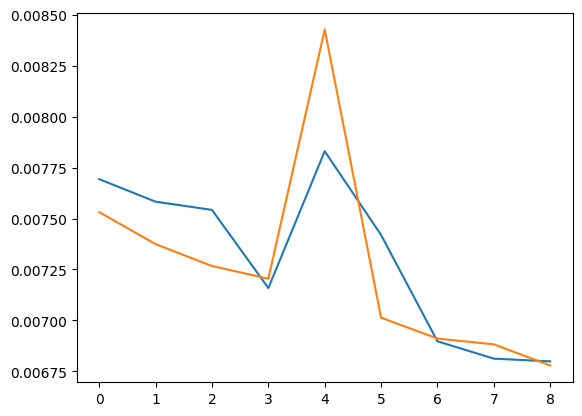

In [41]:
plt.plot(fitHistory.history['mean_absolute_error'][1:])
plt.plot(fitHistory.history['val_mean_absolute_error'][1:])

### Visualize a random image

##  Save the initialization weights

In [54]:
# Do something like this to try another training with the same initialization (e.g.: in the mean absolute error part)

initWeights = fullModel.get_weights()
#fullModel.set_weights(initWeights)

## Lower the learning parameter and run some other epochs

Once you're done save (somewhere) the results

You can also save the model using model.save

# Generalizability of the training

You trained on data with very little noise.
1. Does it generalizes to data with high levels of noise? (load the other file and apply the model)
2. Do the training on the high noise data. What happens to data with low levels of noise

In [55]:
highNoise = np.load('dataNoise_high.npy').astype(np.float32)
highNoise = np.expand_dims(highNoise,axis=-1)
highNoise = np.transpose(highNoise,(2,0,1,3))
highNoiseTrain = highNoise[:1600,:,:,:]
highNoiseTest = highNoise[1600:,:,:,:]